# South Africa Public Procument Analysis

**Setup - Import Libriries & Load cleaned data**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

plt.rcParams["figure.dpi"] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load cleaned datasets
main       = pd.read_csv("../01_cleaned_data/main_clean_cleaned.csv", low_memory=False)
awards     = pd.read_csv("../01_cleaned_data/awards_clean_cleaned.csv")
contracts  = pd.read_csv("../01_cleaned_data/contracts_clean_cleaned.csv")
parties    = pd.read_csv("../01_cleaned_data/parties_clean_cleaned.csv")
suppliers  = pd.read_csv("../01_cleaned_data/awards_suppliers_clean_cleaned.csv")
tenderers  = pd.read_csv("../01_cleaned_data/tender_tenderers_clean_cleaned.csv")


**2. Seasonal Analysis**: 
*Tenders and Value by Month and Quarter*

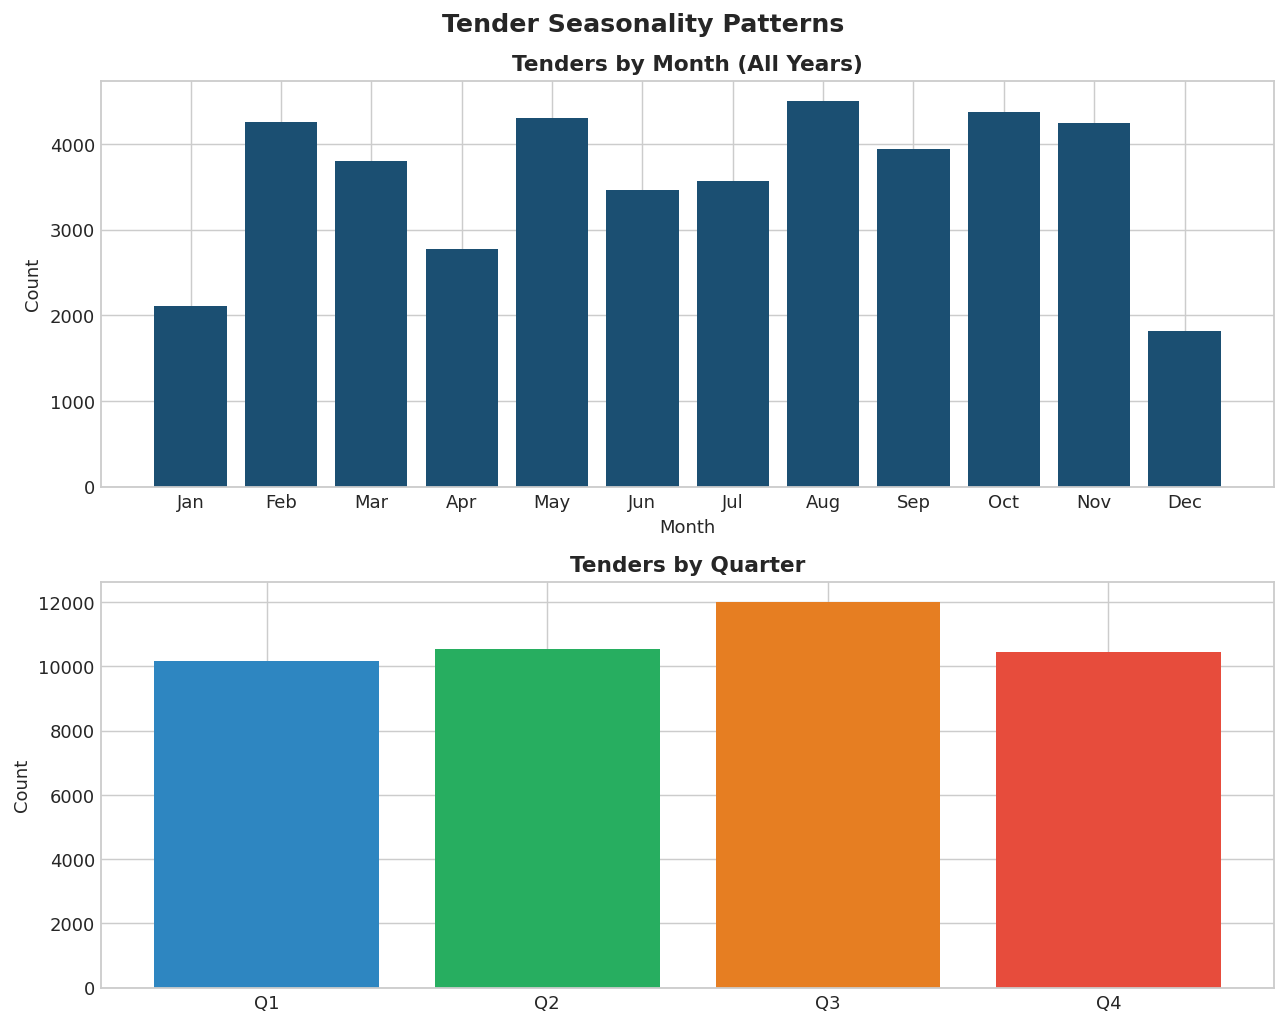

In [19]:
# Convert date columns
main['date'] = pd.to_datetime(main['date'], utc=True, errors='coerce')
main['year'] = main['date'].dt.year
main['month'] = main['date'].dt.month
main['quarter'] = main['date'].dt.quarter

contracts['datesigned'] = pd.to_datetime(contracts['datesigned'], utc=True, errors='coerce')
contracts['period_startdate'] = pd.to_datetime(contracts['period_startdate'], utc=True, errors='coerce')

# Create fig and 2 subplots
fih, axes = plt.subplots(2, 1, figsize=(10, 8))

# Monthly distribution
monthly = main.groupby('month').size()
axes[0].bar(monthly.index, monthly.values, color='#1B4F72')
axes[0].set_title('Tenders by Month (All Years)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])

# Quarterly distribution
quarterly = main.groupby('quarter').size()
colors = ['#2E86C1','#27AE60','#E67E22','#E74C3C']
axes[1].bar(['Q1','Q2','Q3','Q4'], quarterly.values, color=colors)
axes[1].set_title('Tenders by Quarter', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle("Tender Seasonality Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig('../06_outputs/01_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


* WHY: Seasonality is a critical feature for the forecasting model. If Q3 consistently shows higher construction awards (as hypothesized), we can build that into the recommendation engine.

**3. Provincial Analysis**: 
*Tenders and Value by Province*

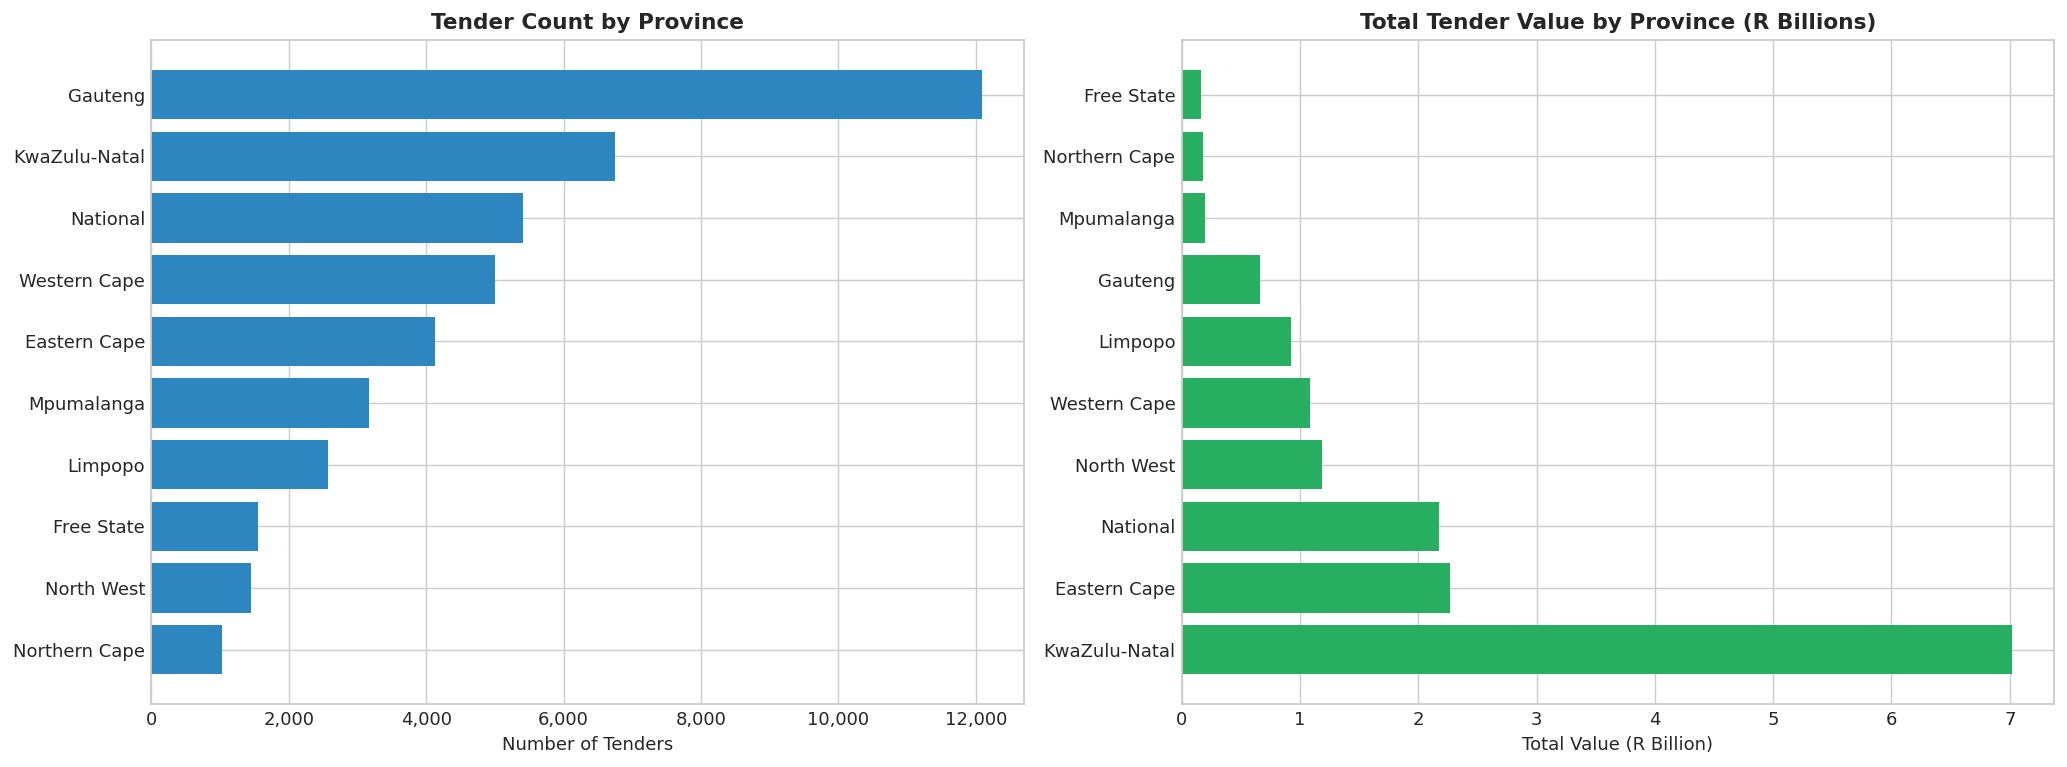

In [20]:
# Provincial Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tender count by province
prov_count = main.groupby('tender_province').size().sort_values(ascending=True)
axes[0].barh(prov_count.index, prov_count.values, color='#2E86C1')
axes[0].set_title('Tender Count by Province', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Tenders')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

main_valued = main[['id', 'tender_province']].merge(
    contracts[['main_id', 'value_amount']],
    left_on='id',
    right_on='main_id',
    how='inner'
)

# Total value by province (exclude zeros)
prov_value = main_valued.groupby('tender_province')['value_amount'].sum().sort_values(ascending=True)
axes[1].barh(prov_value.index, prov_value.values / 1e9, color='#27AE60')
axes[1].set_title('Total Tender Value by Province (R Billions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Value (R Billion)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../06_outputs/02_provincial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



* WHY: Categories reveal the dominant procurement sectors. Construction and IT services typically account for the highest values. This directly feeds the "high-opportunity sector" intelligence output.

**3. Award Value Analysis**: 
*Award Value by Distribution*

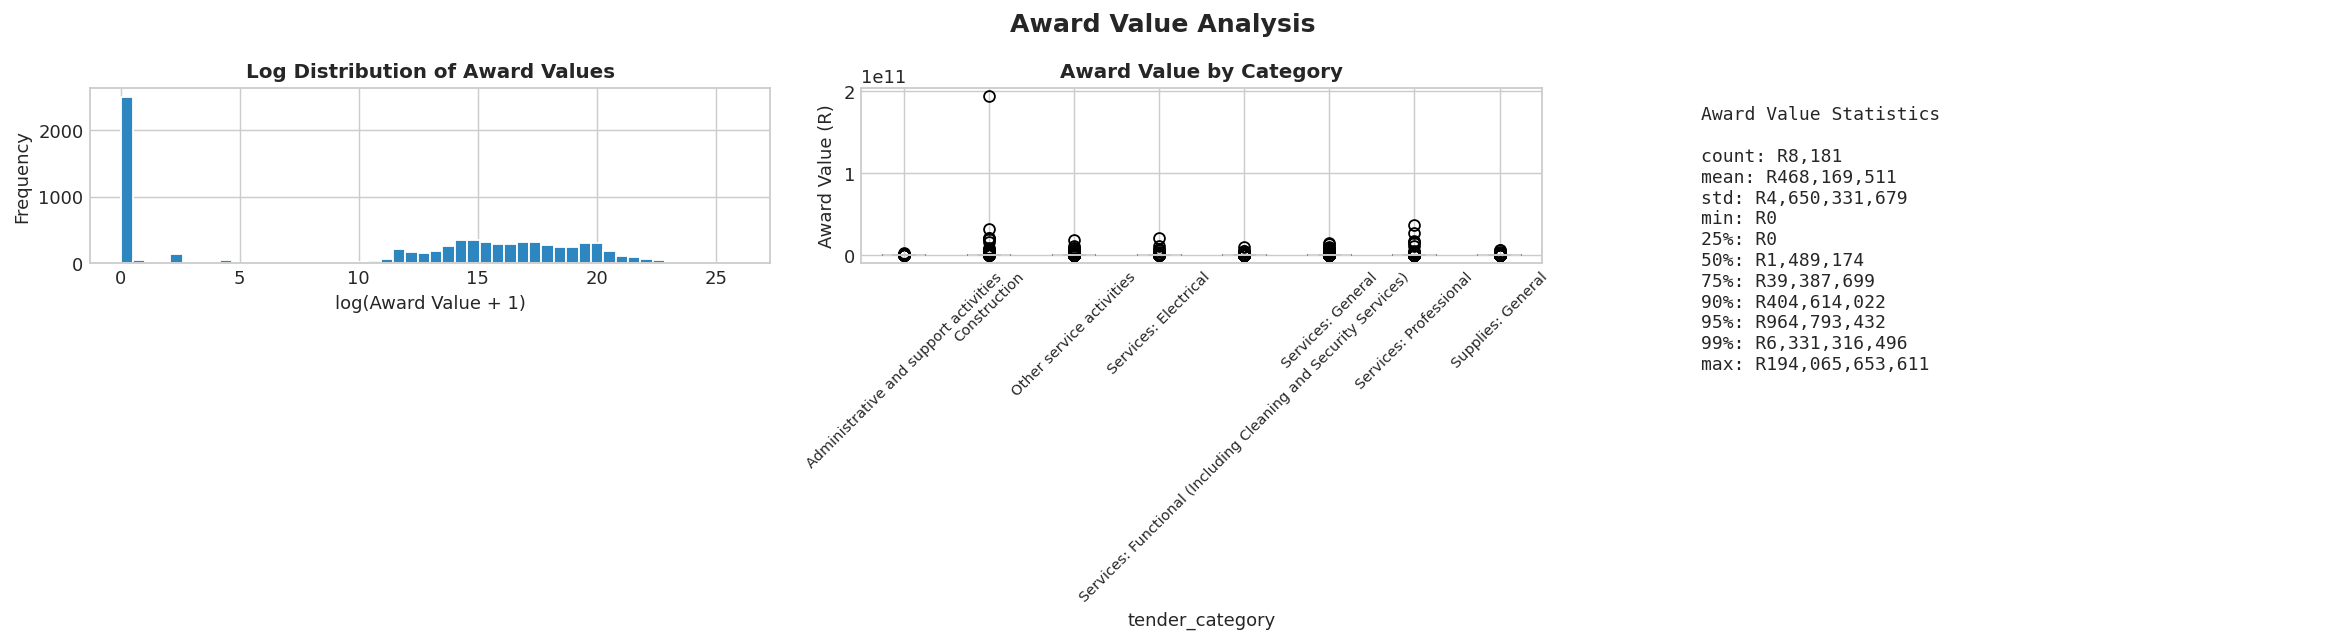

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram (log-transformed)
axes[0].hist(np.log1p(awards['value_amount']), bins=50, color='#2E86C1', edgecolor='white')
axes[0].set_title('Log Distribution of Award Values', fontsize=11, fontweight='bold')
axes[0].set_xlabel('log(Award Value + 1)')
axes[0].set_ylabel('Frequency')

# Box plot by category (top 8)
top_cats = main.groupby('tender_category')['tender_value_amount'].count().nlargest(8).index
merged = awards.merge(main[['ocid','tender_category']], left_on='main_ocid', right_on='ocid', how='left')
merged_top = merged[merged['tender_category'].isin(top_cats)]
merged_top.boxplot(column='value_amount', by='tender_category', ax=axes[1], rot=45)
axes[1].set_title('Award Value by Category', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Award Value (R)')
plt.sca(axes[1])
plt.xticks(fontsize=8)

# Descriptive stats
stats = awards['value_amount'].describe(percentiles=[.25,.5,.75,.9,.95,.99])
axes[2].axis('off')
stat_text = '\n'.join([f'{k}: R{v:,.0f}' for k,v in stats.items()])
axes[2].text(0.1, 0.9, 'Award Value Statistics\n\n' + stat_text,
            transform=axes[2].transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace')

plt.suptitle("Award Value Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig('../06_outputs/03_award_distribution.png', dpi=150, bbox_inches='tight')

* Why: This visualization is critical because public procurement in South Africa is characterized by extreme value inequality.

**4. Top Procurement Categories:** *By Volume and Value*

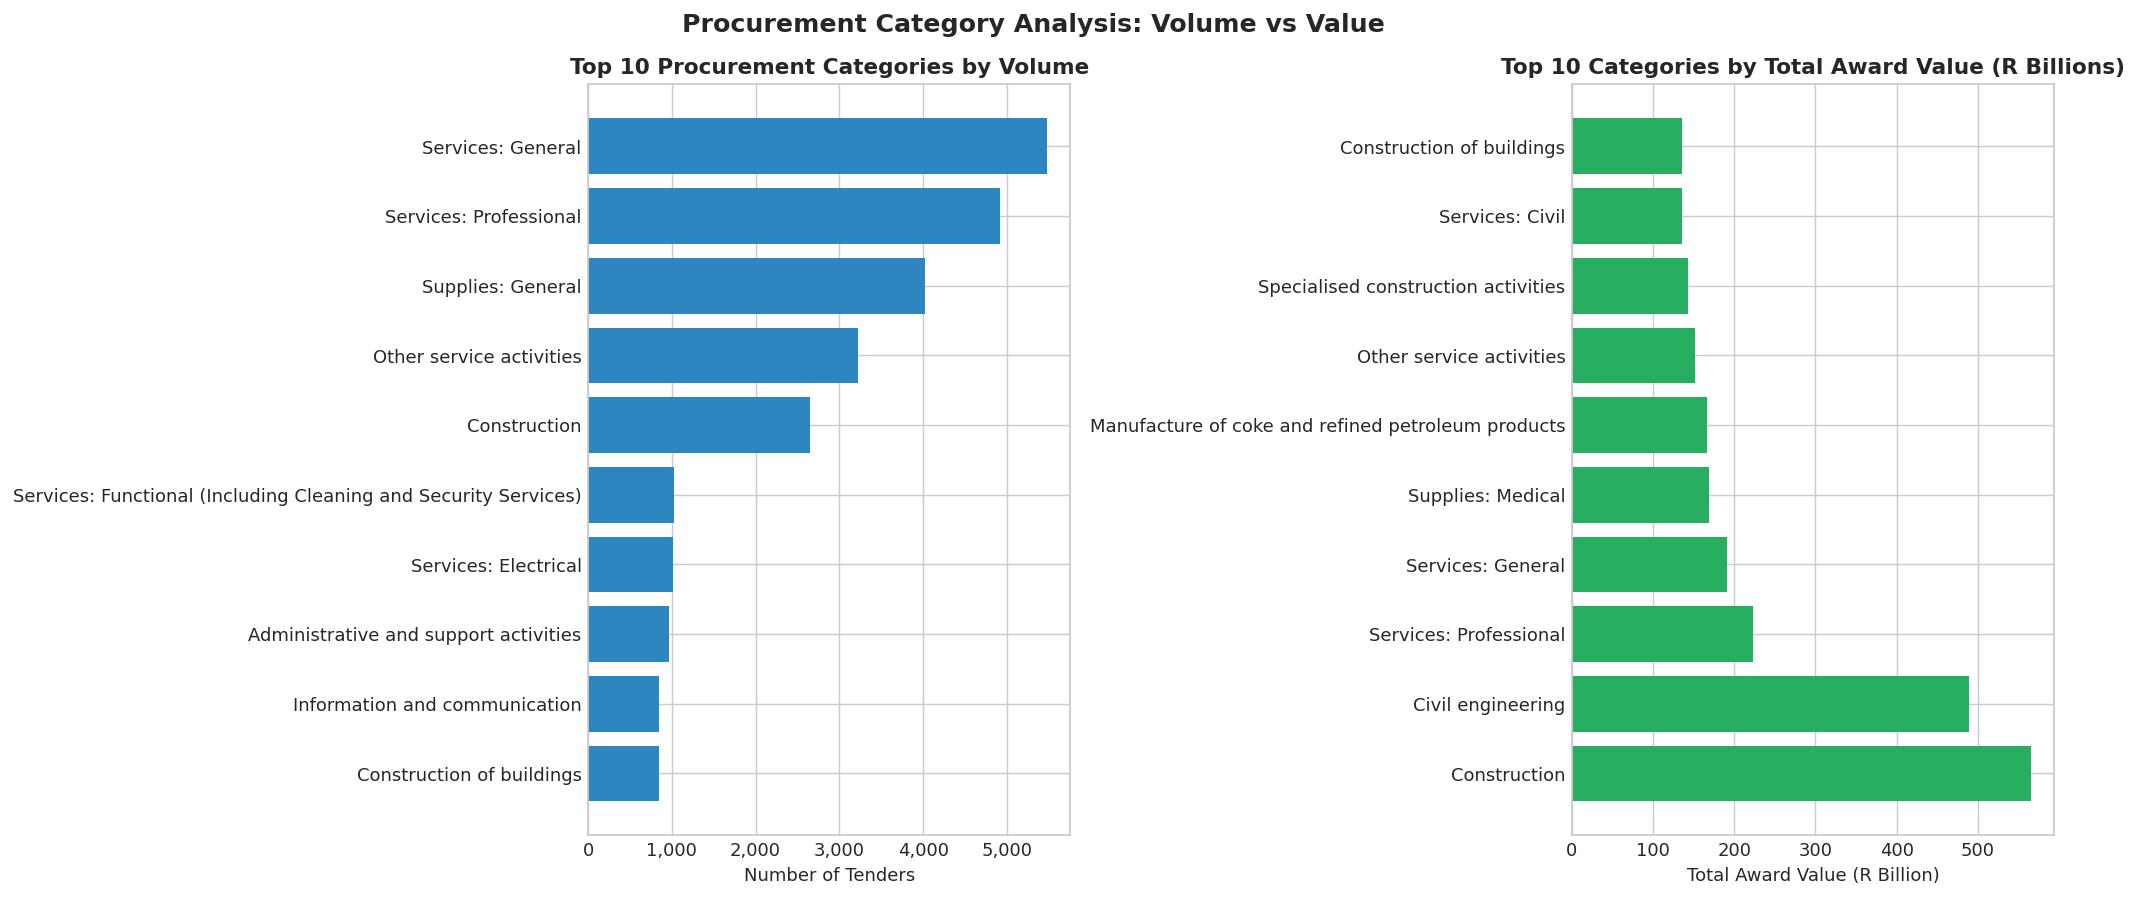

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 Categories by Tender Count
top_cats_count = main['tender_category'].value_counts().head(10)
axes[0].barh(top_cats_count.index[::-1], top_cats_count.values[::-1], color='#2E86C1')
axes[0].set_title('Top 10 Procurement Categories by Volume', fontweight='bold')
axes[0].set_xlabel('Number of Tenders')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Top 10 Categories by Total Award Value
cat_value = (main.merge(awards[['main_ocid', 'value_amount']], 
                left_on='ocid', right_on='main_ocid', how='inner')
            .groupby('tender_category')['value_amount']
            .sum()
            .nlargest(10) / 1e9)

axes[1].barh(cat_value.index[::-1], cat_value.values[::-1], color='#27AE60')
axes[1].set_title('Top 10 Categories by Total Award Value (R Billions)', fontweight='bold')
axes[1].set_xlabel('Total Award Value (R Billion)')
axes[1].invert_yaxis()

plt.suptitle('Procurement Category Analysis: Volume vs Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../06_outputs/04_category_volume_value.png', dpi=150, bbox_inches='tight')
plt.show()

* WHY: This reveals which sectors offer the highest volume of opportunities versus where the real money is concentrated. 
 Suppliers can use this to balance bid volume with potential revenue.

**5. Procurement Method Analysis**

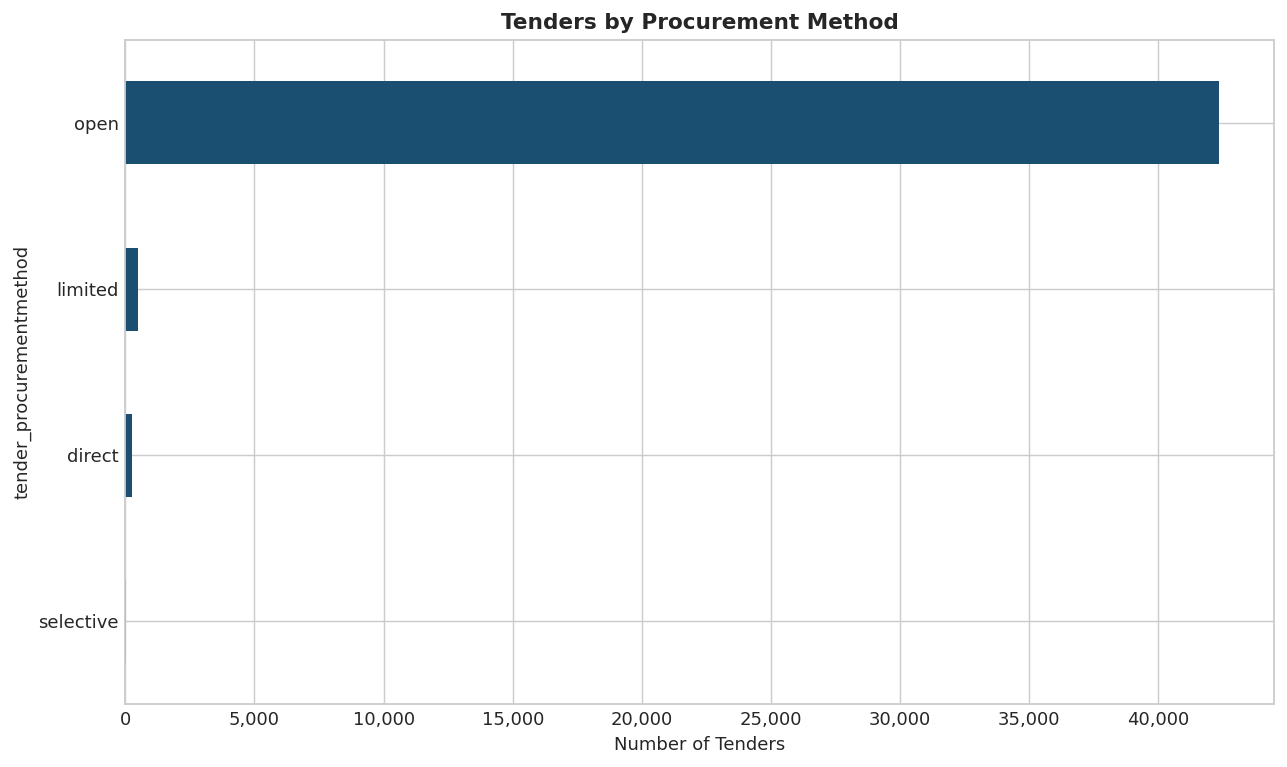

In [25]:
method_stats = main.groupby('tender_procurementmethod').agg(
    tender_count=('id', 'count'),
    avg_value=('tender_value_amount', 'mean'),
    median_value=('tender_value_amount', 'median')
).round(0)

fig, ax = plt.subplots(figsize=(10, 6))
method_stats['tender_count'].sort_values().plot(kind='barh', color='#1B4F72', ax=ax)
ax.set_title('Tenders by Procurement Method', fontweight='bold')
ax.set_xlabel('Number of Tenders')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../06_outputs/05_procurement_method.png', dpi=150, bbox_inches='tight')
plt.show()

* WHY: Although open tenders dominate (98%+), we check whether restricted/limited methods are associated with higher values — a key governance and opportunity signal.

**6. Supplier Analysis**

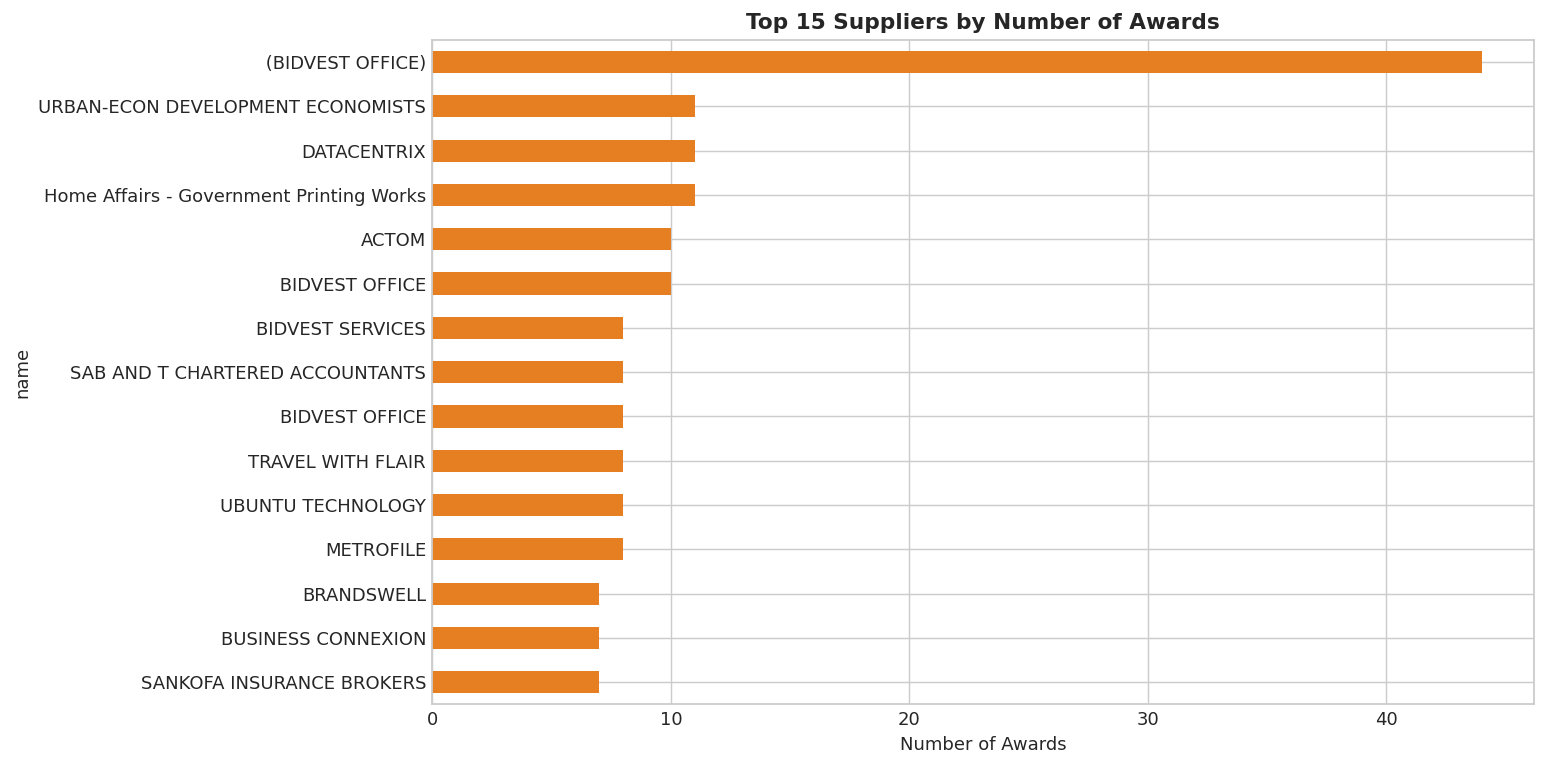

In [26]:
# Top suppliers by number of awards
top_suppliers = suppliers['name'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_suppliers.sort_values().plot(kind='barh', color='#E67E22')
plt.title('Top 15 Suppliers by Number of Awards', fontweight='bold')
plt.xlabel('Number of Awards')
plt.tight_layout()
plt.savefig('../06_outputs/06_top_suppliers_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

* WHY: Identifies supplier concentration and repeat players. High-frequency suppliers may indicate strong relationships or specialization.

**7. Contract Duration Analysis**

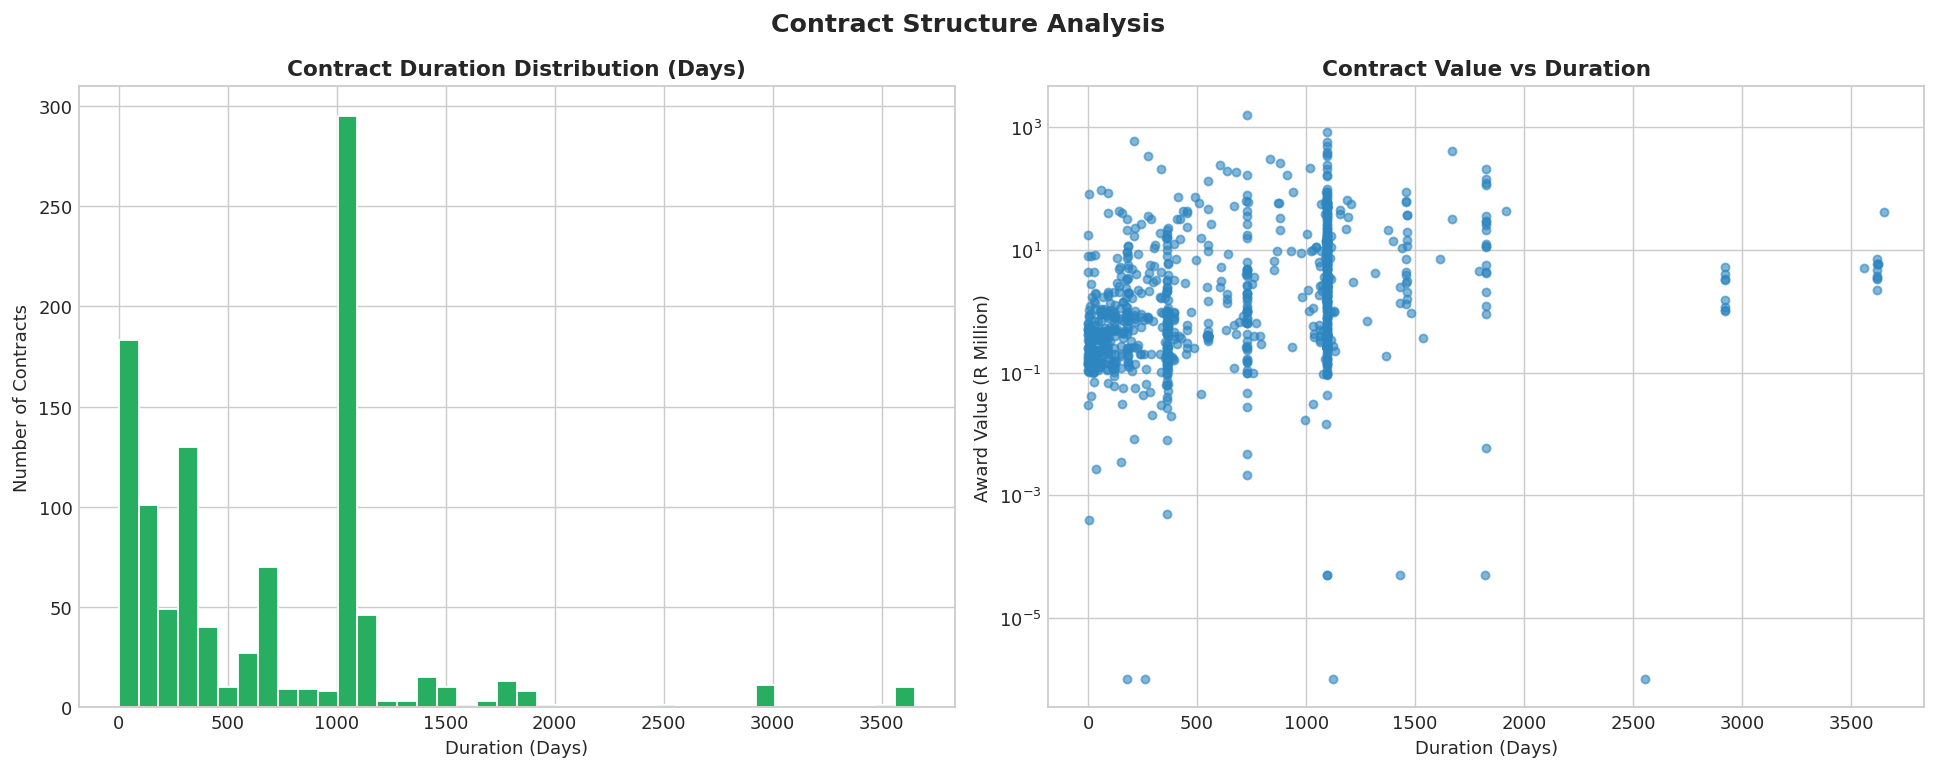

In [27]:
contracts['duration_days'] = (pd.to_datetime(contracts['period_enddate']) - 
                            pd.to_datetime(contracts['period_startdate'])).dt.days

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Duration distribution
axes[0].hist(contracts['duration_days'].dropna(), bins=40, color='#27AE60', edgecolor='white')
axes[0].set_title('Contract Duration Distribution (Days)', fontweight='bold')
axes[0].set_xlabel('Duration (Days)')
axes[0].set_ylabel('Number of Contracts')

# Value vs Duration scatter
merged_duration = contracts.merge(main[['ocid', 'tender_category']], 
                                left_on='main_ocid', right_on='ocid', how='left')
axes[1].scatter(merged_duration['duration_days'], 
                merged_duration['value_amount']/1e6, 
                alpha=0.6, color='#2E86C1', s=20)
axes[1].set_title('Contract Value vs Duration', fontweight='bold')
axes[1].set_xlabel('Duration (Days)')
axes[1].set_ylabel('Award Value (R Million)')
axes[1].set_yscale('log')

plt.suptitle('Contract Structure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../06_outputs/07_contract_duration.png', dpi=150, bbox_inches='tight')
plt.show()

* WHY: Shows whether longer contracts deliver proportionally higher value and helps suppliers understand cash-flow implications of different contract lengths.

**8. Correlation & Feature Relationships**

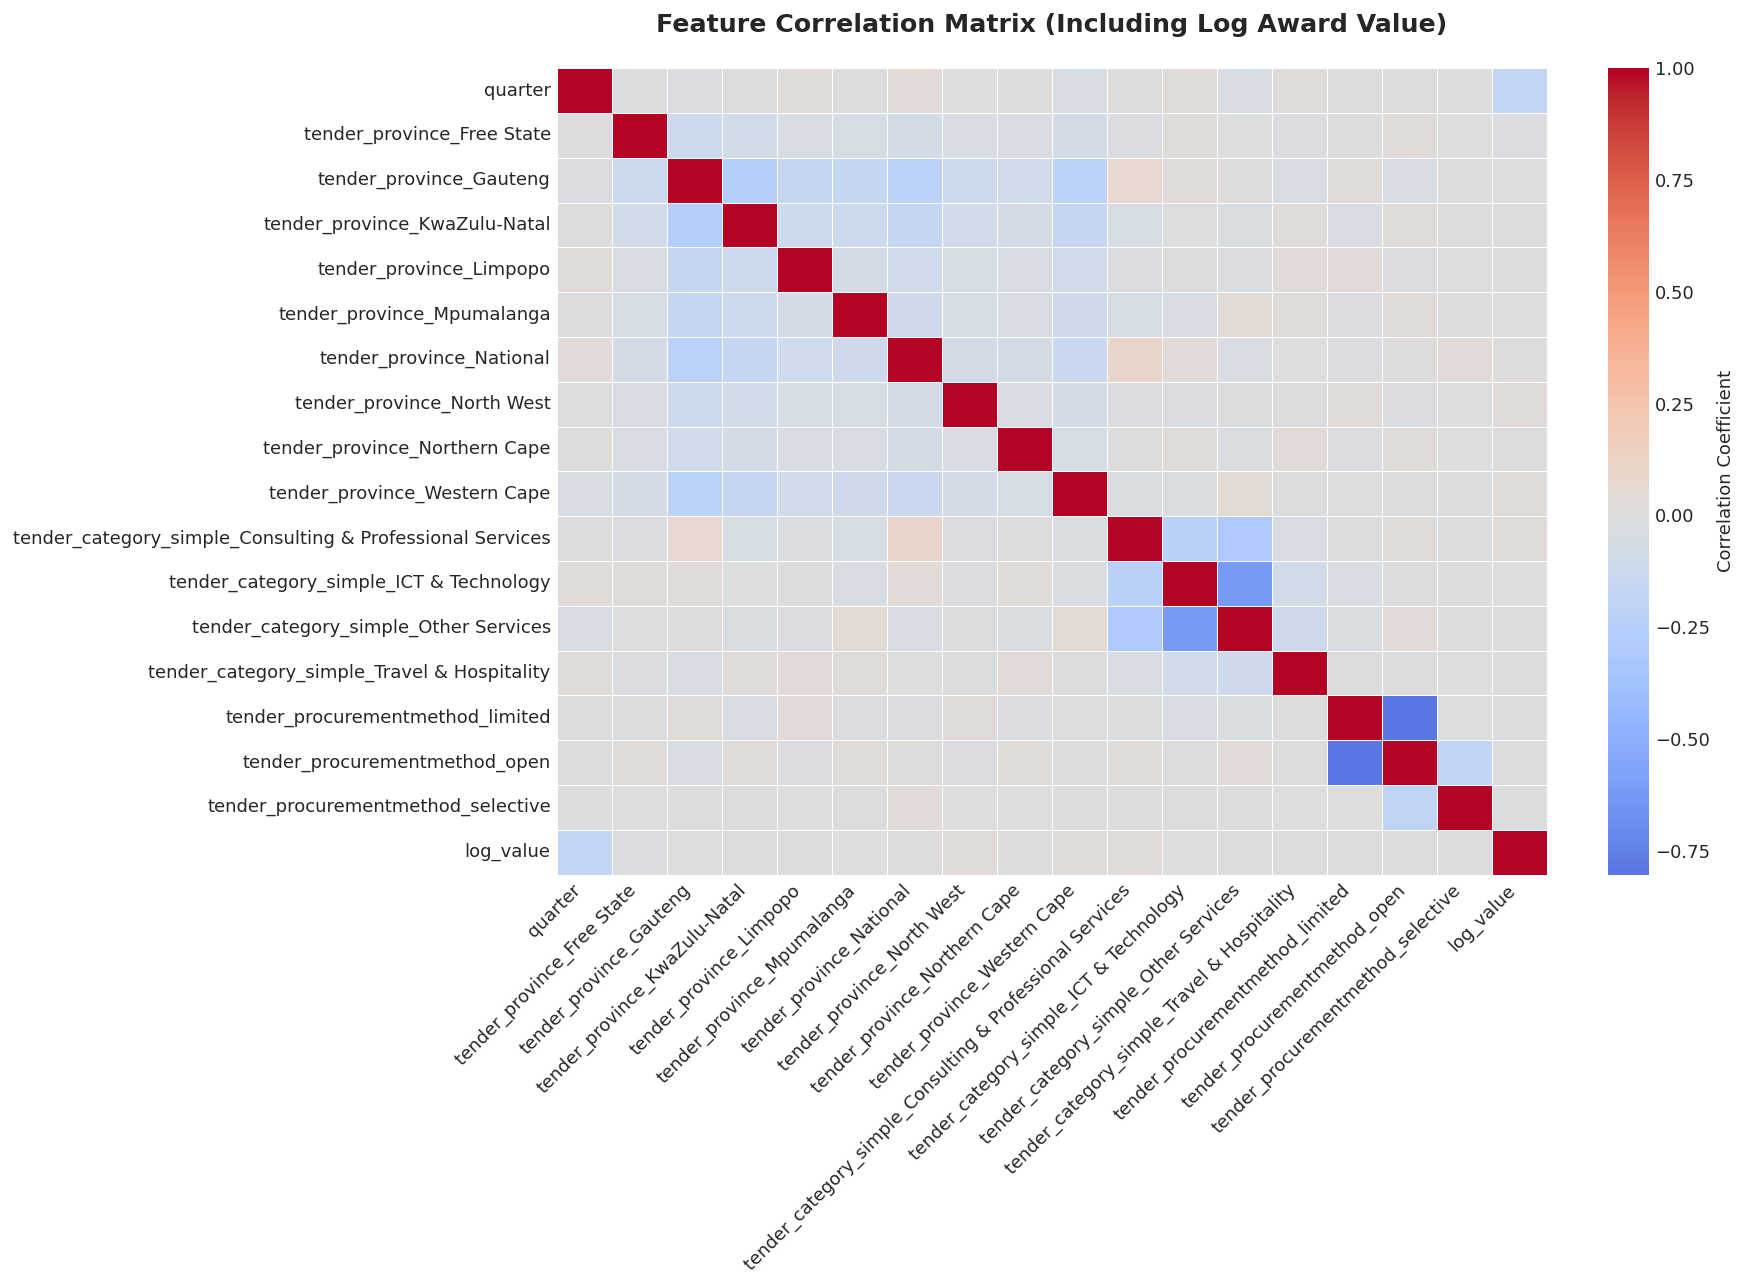

Top correlations with log award value:
log_value                                                    1.000000
tender_province_North West                                   0.022556
tender_category_simple_Consulting & Professional Services    0.022250
tender_province_Western Cape                                 0.016073
tender_province_National                                     0.011237
tender_category_simple_Other Services                        0.008827
tender_category_simple_Travel & Hospitality                  0.005738
tender_province_Northern Cape                                0.002758
tender_procurementmethod_open                                0.002409
tender_province_Mpumalanga                                  -0.001940
tender_province_Gauteng                                     -0.002880
tender_category_simple_ICT & Technology                     -0.004143
tender_procurementmethod_limited                            -0.009174
tender_province_Limpopo                            

In [29]:
# Select only high-level meaningful features (avoid excessive dummies)
features = main[['tender_province', 'tender_category', 'tender_procurementmethod', 
                'month', 'quarter']].copy()

# Create a simplified category grouping to reduce noise
def simplify_category(cat):
    if pd.isna(cat):
        return 'Other'
    cat = str(cat).lower()
    if 'construction' in cat or 'works' in cat or 'civil' in cat:
        return 'Construction & Infrastructure'
    elif 'it' in cat or 'technology' in cat or 'software' in cat or 'computer' in cat:
        return 'ICT & Technology'
    elif 'security' in cat:
        return 'Security Services'
    elif 'cleaning' in cat or 'hygiene' in cat or 'facility' in cat:
        return 'Cleaning & Facilities'
    elif 'travel' in cat or 'catering' in cat or 'accommodation' in cat:
        return 'Travel & Hospitality'
    elif 'consulting' in cat or 'training' in cat or 'professional' in cat:
        return 'Consulting & Professional Services'
    else:
        return 'Other Services'

features['tender_category_simple'] = features['tender_category'].apply(simplify_category)

# One-hot encode only the simplified features
analysis_df = pd.get_dummies(features[['tender_province', 'tender_category_simple', 
                                    'tender_procurementmethod', 'quarter']], 
                            drop_first=True)

# Merge log award value
val_df = (awards[['main_ocid', 'value_amount']]
        .merge(main[['ocid']], left_on='main_ocid', right_on='ocid', how='inner'))

analysis_df = analysis_df.loc[val_df.index]  # align indices
analysis_df['log_value'] = np.log1p(val_df['value_amount'].values)

# Compute correlation
corr = analysis_df.corr()

# Plot clean correlation heatmap (focus on relationships with log_value)
plt.figure(figsize=(14, 10))

# Only show correlations with log_value + key features to avoid clutter
key_corr = corr[['log_value']].sort_values(by='log_value', ascending=False)

sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5, 
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Feature Correlation Matrix (Including Log Award Value)', 
        fontweight='bold', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('../06_outputs/8_correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# Optional: Top correlations with target (log_value)
print("Top correlations with log award value:")
print(corr['log_value'].sort_values(ascending=False).head(15))

* WHY: Reveals relationships and potential multicollinearity (e.g., month vs quarter) to guide feature engineering for the ML forecasting model.